<a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-15th/blob/junmo/advanced/junmo/session04/%EC%96%B8%EC%96%B4%EB%AA%A8%EB%8D%B8_%EC%98%88%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP와 언어 모델 정리

## NLP

자연어 처리. 인간이 쓰는 언어를 컴퓨터가 이해하고 처리할 수 있도록 하는 AI 기술 분야임

자연어는 프로그래밍 언어랑 달리 모호하고 문맥에 따라 의미가 바뀌는 특성이 있음. 같은 단어라도 상황마다 다른 뜻을 가질 수 있어서 컴퓨터한테는 어려운 대상임

NLP가 하는 일은 결국 이 모호한 글자들을 컴퓨터가 계산할 수 있는 숫자로 바꾸고 의미를 뽑아내는 거임. 실제 활용 분야는 음성 인식, 번역, 요약, 감정 분석, 챗봇 등이 있음

자연어의 특징 몇 가지를 짚고 가면

- 이산적 데이터임. 이미지는 연속적인 신호인데 언어는 단어라는 딱 끊어지는 단위로 구성됨. 그래서 벡터로 변환하는 작업이 필요함
- 순서가 중요함. 사자가 사람을 먹다 vs 사람이 사자를 먹다는 완전히 다른 문장임
- 중의성이 있음. 배라는 단어가 과일인지 배인지 위인지 문맥 봐야 알 수 있음
- 희소성 문제가 있음. 단어 조합이 거의 무한한데 실제 데이터에 나타나는 건 극히 일부임
- 계속 변함. 신조어, 은어, 이모지 같은 게 계속 생겨남

---

## 통계 기반 언어 모델

### SLM

통계 기반 언어 모델임. 핵심 아이디어는 분포 가설에서 나옴

### 분포 가설

비슷한 문맥에서 함께 등장하는 단어들은 비슷한 의미를 가진다는 가설임

예를 들어 I play soccer, I play basketball, I play tennis 이런 문장들에서 soccer, basketball, tennis는 같은 문맥에 등장하니까 모델이 이것들이 비슷한 범주에 속한다고 학습하게 됨

이걸 구현하는 방식이 조건부 확률이랑 카운트 기반 확률임

앞에 나온 단어들을 보고 다음 단어가 뭐가 올지 확률로 예측하는 거임. 예를 들어 나는 버스를 까지 나왔을 때 다음에 탔다가 올 확률이 높다는 식으로 계산함

문제는 학습 데이터에서 한 번도 본 적 없는 단어 조합이 나오면 확률을 아예 0으로 처리해버림. 이게 희소 문제임

---

### N-gram

SLM이 문장 전체를 보려다 보니 길어질수록 계산이 너무 힘들어짐. 그래서 전체 문장 대신 일부만 보자는 아이디어에서 나온 게 N-gram임

N개 단어를 하나의 단위로 보는 것임. uni는 1개씩, bi는 2개씩, tri는 3개씩 보는 식임

다음 단어를 예측할 때 N-1개의 단어를 참고함. N-1인 이유는 예측하려는 단어까지 합쳐서 총 N개가 되기 때문임

확률적으로 더 많이 등장한 것을 선택하는 건 SLM이랑 동일함. 다만 문장 전부 대신 앞 N-1개만 보고 계산하는 차이가 있음

#### N-gram이 나온 배경

SLM이 문장이 길어질수록 계산이 어렵고 희소한 데이터에 약하니까, 전체 대신 일부만 보는 방식으로 대안을 낸 거임

#### N-gram의 한계

- 여전히 희소 문제가 있음. 훈련 데이터에 없는 단어 조합은 확률 0이 됨. N이 커질수록 이 문제가 더 심각해짐
- 문맥 제한. 앞 N-1개 단어만 보기 때문에 문장 앞부분 정보를 뒷부분에 반영하지 못함

---

### PPL

Perplexity. 언어 모델이 문장을 얼마나 혼란스러워하는지를 수치로 나타낸 것임

PPL이 낮을수록 모델이 예측에 덜 헷갈린다는 뜻이고 성능이 좋다는 뜻임

문장이 희소하게 등장할수록 PPL이 올라가고, 단어 개수가 많아질수록 PPL이 낮아짐

---

## 신경망 언어 모델
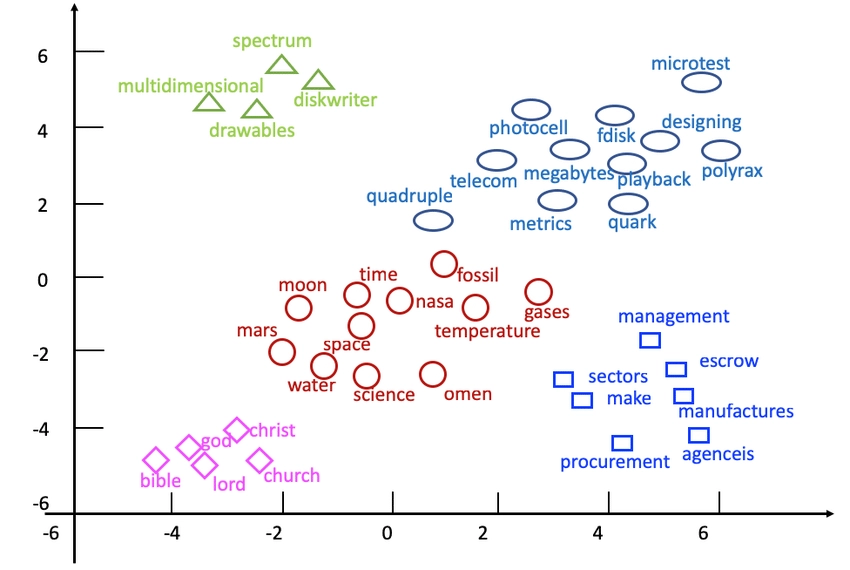
### NLM

통계 기반 모델의 한계를 극복하려고 등장한 게 신경망 언어 모델임. 핵심 키워드는 임베딩임

임베딩이란 단어를 숫자 벡터로 변환하는 것임. 인간의 언어를 컴퓨터의 언어로 번역하는 다리 같은 역할임

### SLM과의 차이

SLM은 단어를 그냥 이름으로만 기억함. 축구랑 농구는 그냥 완전히 다른 두 단어임

NLM은 모든 단어를 다차원 공간 위의 좌표로 표현함. 이게 워드 임베딩임. 축구랑 농구를 이 공간에 찍어보면 둘 다 구기 종목이고 스포츠라는 공통점 때문에 가까이 위치하게 됨

그래서 SLM은 학습 데이터에 재밌는 축구를 한다는 문장이 없으면 확률을 0으로 처리하는데, NLM은 재밌는 농구를 한다를 학습했고 축구와 농구가 유사한 벡터라는 것도 알기 때문에 처음 보는 문장에도 어느 정도 확률을 부여할 수 있음

이 일반화 능력이 SLM과 NLM의 가장 큰 차이임

---

## 딥러닝 기반 언어 모델

### Transformer

RNN이랑 LSTM이 가진 문제가 있었음. 순차적으로 처리해야 해서 병렬화가 안 되고, 기울기 소실 문제, 긴 문장에서의 장기 의존성 문제 등임. 이게 신경망을 깊게 못 쌓게 만드는 원인이었음

이걸 해결한 게 트랜스포머임

트랜스포머는 인코더와 디코더를 여러 층으로 깊게 쌓는 구조임. RNN처럼 같은 셀을 반복 사용하는 게 아니라 여러 층을 쌓아서 처리함

인코더는 문장 전체를 입력받아 단어 간 관계를 계산하고 의미 벡터로 변환함. 디코더는 인코더 출력이랑 이전까지 생성한 단어들을 참고해서 다음 단어를 생성함. 미래 단어는 보지 않음

이 구조 덕분에 신경망을 깊게 쌓을 수 있게 됐고 언어 모델의 표현력이 크게 높아짐

트랜스포머 등장 이후 전이학습이 NLP의 표준 방법론이 됨

- 사전 학습: 레이블 없는 방대한 데이터로 언어의 구조, 상식, 문맥을 전반적으로 학습시킴
- 파인 튜닝: 사전 학습된 모델에 특정 작업의 데이터를 추가로 조금 학습시켜서 특정 분야 전문가로 만듦

---

### BERT

Bidirectional Encoder Representations from Transformers임

트랜스포머의 인코더 부분만 사용함. 양방향으로 작동해서 한 단어를 이해할 때 좌우 문맥을 동시에 봄

단방향 모델은 한강을 이해할 때 앞에 나온 나는, 어제만 참고하는데, BERT는 뒤에 나오는 피자를, 먹었다까지 다 참고해서 한강이 음식 먹은 장소라는 걸 파악할 수 있음

인코더만 사용하기 때문에 문장 생성보다는 문장 이해에 특화됨. 감정 분석, 스팸 분류, 검색 엔진 같은 데 씀

사전 학습 방법이 독특함

첫 번째는 MLM임. 문장의 15% 정도 단어를 가리고 빈칸에 뭐가 들어갈지 맞추게 함. 빈칸 채우기로 학습하면서 자연스럽게 문맥 이해 능력이 생김

두 번째는 NSP임. 두 문장이 실제로 이어지는 문장인지 아니면 무작위로 고른 두 문장인지 맞추게 함. 이걸 통해 두 문장 사이의 논리적 흐름을 학습함

BERT 이후로 RoBERTa, ALBERT 같은 모델들이 나왔음. RoBERTa는 더 많은 데이터와 더 긴 학습으로 성능을 높인 버전이고, ALBERT는 경량화 버전임

---

### GPT

트랜스포머의 디코더 기반 모델임

디코더는 미래 단어를 가리기 때문에 GPT도 왼쪽 단어들만 보고 오른쪽에 올 단어를 예측함. 이게 문장 생성에 특화된 이유임

GPT-3부터 few-shot learning이 도입됨. 예시를 몇 개 보여주면 그걸 참고해서 새로운 작업을 수행하는 거임

- zero-shot은 예시 없이 지시만으로 수행
- one-shot은 예시 1개
- few-shot은 예시 몇 개를 보고 수행

---

### LLM

Large Language Model, 거대 언어 모델임. BERT랑 GPT에 이어 등장한 개념임

GPT 구조, 즉 디코더 기반을 사용함. 문장 이해에서 그치지 않고 텍스트를 생성하는 게 목적이기 때문임

LLM의 주요 특징들

첫 번째는 스케일링 법칙임. 모델 크기, 데이터 양, 계산량이 일정 임계치를 넘으면 성능이 지수적으로 폭발적으로 증가함

두 번째는 창발적 능력임. 단순히 다음 단어 맞추기만 학습했는데 갑자기 예상치 못한 능력들이 생겨남. 수학 문제를 풀거나 논리 추론을 하거나 하는 것들임

세 번째는 RLHF임. Reinforcement Learning from Human Feedback, 인간 피드백 기반 강화학습임. 사람이 여러 답변 중 좋은 걸 골라주면 모델이 그 선호를 학습함. 이걸 통해 환각을 줄이고 안전한 답변을 유도함

네 번째는 패러다임 전환임. 예전에는 데이터 모아서 모델을 다시 학습시키는 파인 튜닝 중심이었는데, 이제는 모델 고정하고 입력을 정교하게 짜는 프롬프트 엔지니어링 중심으로 바뀜

LLM의 한계도 있음. 환각 문제가 있고, 학습 시점 이후 새로운 정보를 반영하기 어렵고, 업데이트 비용이 매우 큼

---

### RAG

LLM은 학습 당시의 지식만 갖고 있어서 그 이후 새로운 정보에 대해서는 답을 못 함

그래서 외부에서 최신 정보를 가져와서 답하게 하는 구조가 RAG임. Retrieval Augmented Generation임

쉽게 말하면 모델이 모르는 거 있으면 검색해서 답하는 구조임

#### RAG의 구조

크게 세 부분으로 나뉨

- 질의 인코더: 사용자 질문을 벡터로 변환함
- 지식 검색기: 변환된 질문 벡터를 가지고 외부 지식에서 관련 내용을 검색함
- 지식 증강 생성기: 검색한 내용을 참고해서 최종 답변을 생성함

장점은 최신 정보를 반영할 수 있고, 모르는 걸 검색으로 보완하니까 환각 문제도 줄어들고 정확도도 올라감

---

### LangChain

LLM에 RAG를 붙이는 등 모델 파이프라인을 직접 구현하면 복잡함. 이걸 쉽게 연결할 수 있도록 도와주는 프레임워크가 LangChain임

#### LangChain의 아이디어와 특징

핵심 아이디어는 LLM 기반 앱을 레고 블럭처럼 조립할 수 있게 하는 것임

특징은 세 가지임

첫 번째는 추상화임. 문서 불러오기, 임베딩, 벡터 DB 저장 같은 복잡한 작업들을 몇 줄로 간결하게 표현할 수 있음. 랭체인 없이 짜면 수십 줄인 게 랭체인 쓰면 몇 줄로 끝남

두 번째는 표준화임. 비슷한 기능을 하는 요소들을 동일한 형식의 컴포넌트로 만들어서 쉽게 교체하고 조합할 수 있게 함

세 번째는 체이닝임. 주요 컴포넌트들을 연결해서 입력부터 출력까지의 로직을 명확하게 볼 수 있게 함

LangChain의 한계도 있음. 중간에 조건에 따라 다른 작업을 해야 하거나, 결과가 맘에 안 들면 이전 단계로 돌아가서 다시 해야 하는 복잡한 로직을 구현하기 어려움

이걸 해결하려고 나온 게 LangGraph임. 비선형적인 작업 형태로 사이클이나 루프를 만들 수 있음. 노드는 특정 작업 단위이고, 엣지는 노드 사이 연결이랑 이동 방향을 결정함. 조건부 엣지로 if-else 분기 로직도 구현 가능함

---

## sLM

small Language Model임. LLM보다 규모가 작은 언어 모델임

LLM이 수천억 ~ 수조 개의 매개변수를 가진다면, sLM은 수백만 ~ 수십억 개 수준임

크기가 작아서 메모리랑 연산 자원을 적게 써서 모바일 앱이나 오프라인 환경처럼 리소스가 제한된 상황에 적합함

---

### 모델 압축

LLM을 작게 만드는 방법들임

첫 번째는 가지치기임. 신경망에서 중요도가 낮거나 불필요한 매개변수를 제거하는 것임. 뉴런 간 연결 가중치, 뉴런 자체, 또는 레이어를 제거함

두 번째는 양자화임. 고정밀 데이터를 저정밀 데이터로 변환하는 것임. 예를 들어 32비트 부동소수점을 8비트 정수로 바꾸는 거임. 계산 부하를 줄이고 추론 속도를 높일 수 있음

세 번째는 저차원 분해임. 큰 가중치 행렬을 더 작은 저차원 행렬로 분해하는 것임. 매개변수 수가 줄고 복잡한 행렬 연산을 단순화할 수 있음. SVD가 대표적인 기법임

네 번째는 지식 증류임. 큰 교사 모델의 학습 내용을 작은 학생 모델로 이전하는 것임. 학생 모델이 교사 모델의 예측을 따라 하고 추론 과정을 모방하도록 학습함

---

### sLM의 장점

성능 측면에서는

- 특정 작업에 맞게 파인 튜닝하면 그 작업을 빠르고 안정적으로 수행 가능함
- 모델이 작아서 계산량이 적고 지연 시간이 줄어듦
- 기업 내부 서버나 개인 기기에서 직접 실행 가능해서 보안에 유리함. 민감한 데이터를 외부로 안 보내도 됨

비용 측면에서는

- 고성능 GPU 없어도 쓸 수 있어서 진입 장벽이 낮음
- 저장 공간, 메모리, 연산 자원 다 적게 씀
- 전력 소비도 낮고 API 호출 비용도 저렴함

### sLM의 한계

- 더 큰 모델에 있는 편향이 같이 전달될 수 있음
- 특정 작업용으로 파인 튜닝하다 보니 포괄적인 지식이 필요한 작업에 취약함
- 정보가 적고 추론 능력이 낮아서 환각이 발생할 수 있음

---

### sLM과 LLM의 결합

복잡하고 어려운 작업에는 LLM, 가볍고 간단한 작업에는 sLM을 배분해서 쓰는 방식임

이렇게 결합하면 LLM 수준의 높은 정확도를 유지하면서도 LLM 토큰 사용량을 최대 90%까지 줄일 수 있다고 함